# Getting data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import statsmodels.api as sm
import statsmodels.formula.api as smf




In [3]:
full_df = pd.read_csv("newborn_health_monitoring_with_risk.csv")

In [4]:
colNames = full_df.columns
print(colNames)

Index(['baby_id', 'name', 'gender', 'gestational_age_weeks', 'birth_weight_kg',
       'birth_length_cm', 'birth_head_circumference_cm', 'date', 'age_days',
       'weight_kg', 'length_cm', 'head_circumference_cm', 'temperature_c',
       'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation',
       'feeding_type', 'feeding_frequency_per_day', 'urine_output_count',
       'stool_count', 'jaundice_level_mg_dl', 'apgar_score',
       'immunizations_done', 'reflexes_normal', 'risk_level'],
      dtype='object')


Null percentages for each column

In [5]:
for col in colNames:
    nullValues = full_df[col].isnull().sum()
    print(f"{col}: {nullValues}")

baby_id: 0
name: 0
gender: 0
gestational_age_weeks: 0
birth_weight_kg: 0
birth_length_cm: 0
birth_head_circumference_cm: 0
date: 0
age_days: 0
weight_kg: 0
length_cm: 0
head_circumference_cm: 0
temperature_c: 0
heart_rate_bpm: 0
respiratory_rate_bpm: 0
oxygen_saturation: 0
feeding_type: 0
feeding_frequency_per_day: 0
urine_output_count: 0
stool_count: 0
jaundice_level_mg_dl: 0
apgar_score: 2900
immunizations_done: 0
reflexes_normal: 0
risk_level: 0


In [6]:
#Only first day

firstDayDF = full_df[full_df["age_days"] == 1]

# Gender 

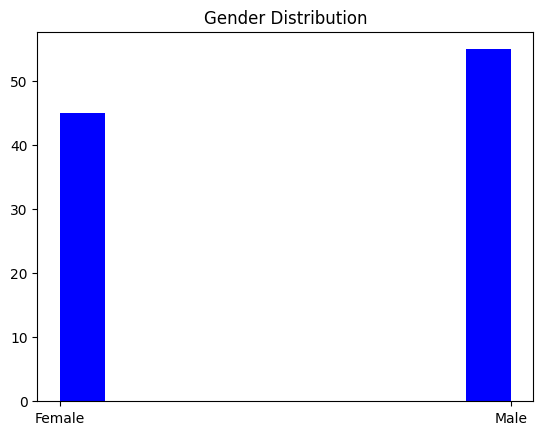

Males: 55
Females: 45


In [7]:
#Plotting 
plt.title("Gender Distribution")
plt.hist(firstDayDF["gender"], color="blue")
plt.show()

males = (firstDayDF["gender"] == "Male").sum()
females = (firstDayDF["gender"] == "Female").sum()
print(f"Males: {males}")
print(f"Females: {females}")


# Gestational Age

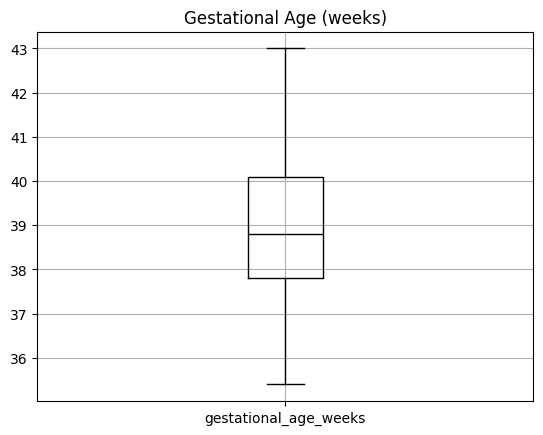

In [8]:
plt.title("Gestational Age (weeks)")
firstDayDF.boxplot("gestational_age_weeks", color="black")
plt.show()

In [9]:
#5 Number sumamry for gestational age
firstDayDF["gestational_age_weeks"].describe()

count    100.000000
mean      38.878000
std        1.577722
min       35.400000
25%       37.800000
50%       38.800000
75%       40.100000
max       43.000000
Name: gestational_age_weeks, dtype: float64

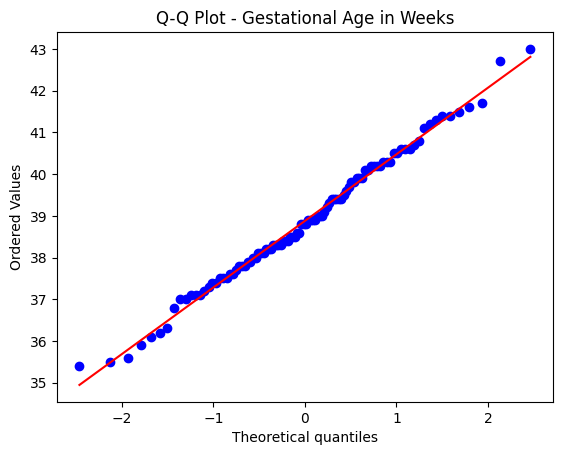

In [10]:
stats.probplot(firstDayDF["gestational_age_weeks"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Gestational Age in Weeks")
plt.show()

In [11]:
stat, p = shapiro(firstDayDF["gestational_age_weeks"])
print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Fail to reject H0: data looks normally distributed")
else:
    print("Reject H0: data is NOT normally distributed")

Shapiro-Wilk p-value: 0.8078680337939202
Fail to reject H0: data looks normally distributed


# Temperature

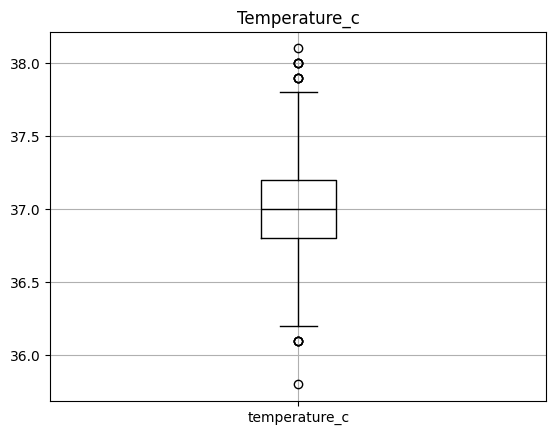

In [12]:
plt.title("Temperature_c")
full_df.boxplot("temperature_c", color="black")
plt.show()

In [13]:
#5 Number sumamry for temperature
full_df["temperature_c"].describe()

count    3000.000000
mean       37.002933
std         0.310747
min        35.800000
25%        36.800000
50%        37.000000
75%        37.200000
max        38.100000
Name: temperature_c, dtype: float64

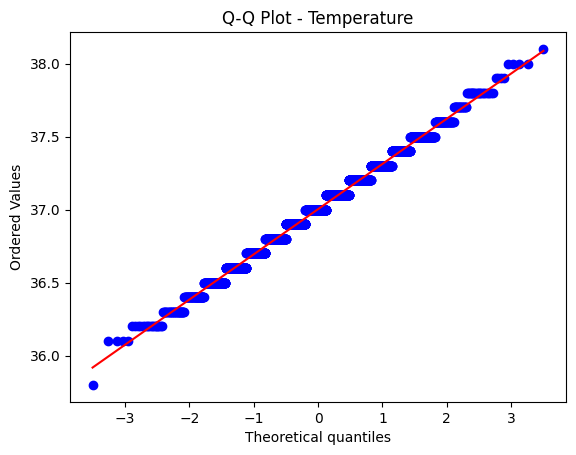

In [14]:
stats.probplot(full_df["temperature_c"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Temperature")
plt.show()

In [15]:
stat, p = shapiro(firstDayDF["gestational_age_weeks"])
print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Fail to reject H0: data looks normally distributed")
else:
    print("Reject H0: data is NOT normally distributed")

Shapiro-Wilk p-value: 0.8078680337939202
Fail to reject H0: data looks normally distributed


# Heart Rate

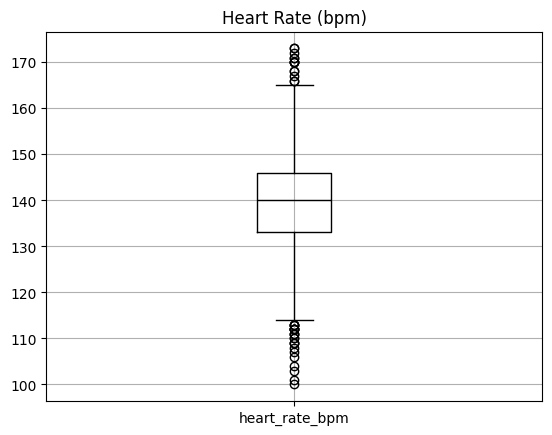

In [16]:
plt.title("Heart Rate (bpm)")
full_df.boxplot("heart_rate_bpm", color="black")
plt.show()

In [17]:
full_df["heart_rate_bpm"].describe()

count    3000.000000
mean      139.682000
std        10.139386
min       100.000000
25%       133.000000
50%       140.000000
75%       146.000000
max       173.000000
Name: heart_rate_bpm, dtype: float64

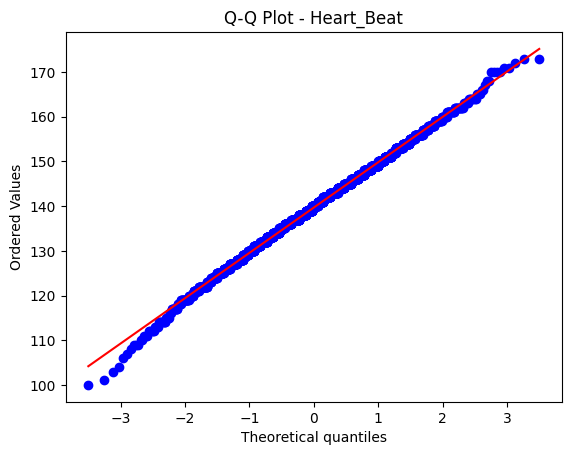

In [41]:
stats.probplot(full_df["heart_rate_bpm"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Heart_Beat")
plt.show()

In [19]:
stat, p = shapiro(full_df["heart_rate_bpm"])
print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Fail to reject H0: data looks normally distributed")
else:
    print("Reject H0: data is NOT normally distributed")

Shapiro-Wilk p-value: 0.0002747332626884414
Reject H0: data is NOT normally distributed


# Feeding Type

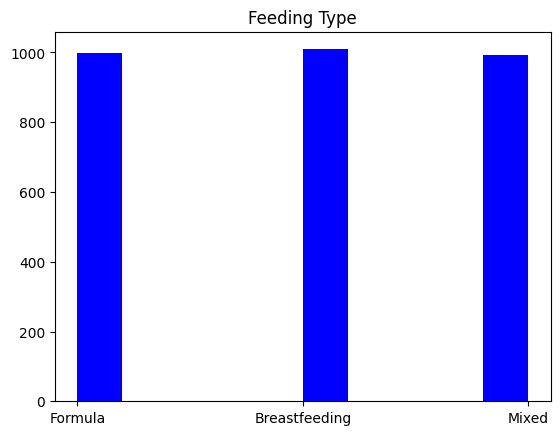

Formulas: 998
Breastfed: 1009
Mixed: 993


In [20]:
#Plotting 
plt.title("Feeding Type")
plt.hist(full_df["feeding_type"], color="blue")
plt.show()

formula = (full_df["feeding_type"] == "Formula").sum()
breastfed = (full_df["feeding_type"] == "Breastfeeding").sum()
mixed = (full_df["feeding_type"] == "Mixed").sum()
print(f"Formulas: {formula}")
print(f"Breastfed: {breastfed}")
print(f"Mixed: {mixed}")

# Number of Feedings

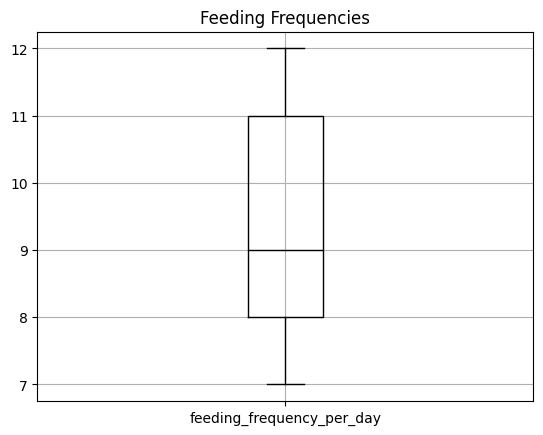

In [21]:
plt.title("Feeding Frequencies")
full_df.boxplot("feeding_frequency_per_day", color="black")
plt.show()

In [22]:
full_df["feeding_frequency_per_day"].describe()

count    3000.000000
mean        9.450000
std         1.707182
min         7.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        12.000000
Name: feeding_frequency_per_day, dtype: float64

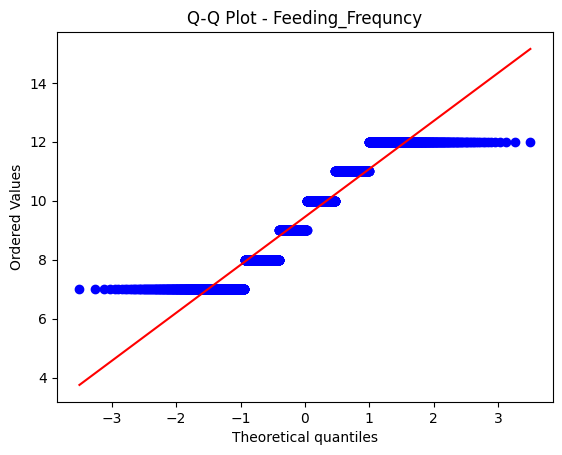

In [42]:
stats.probplot(full_df["feeding_frequency_per_day"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Feeding_Frequncy")
plt.show()

In [24]:
stat, p = shapiro(full_df["feeding_frequency_per_day"])
print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Fail to reject H0: data looks normally distributed")
else:
    print("Reject H0: data is NOT normally distributed")

Shapiro-Wilk p-value: 1.561645491043413e-39
Reject H0: data is NOT normally distributed


# Jaundice

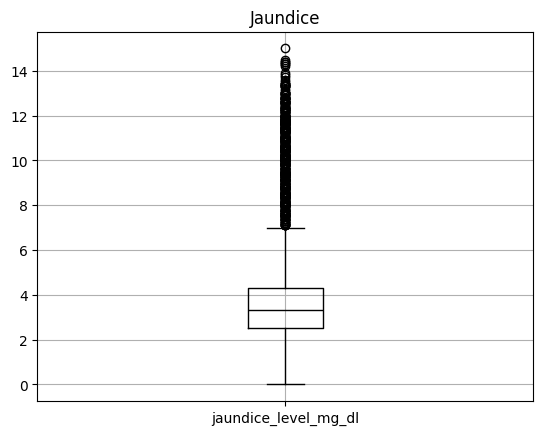

In [25]:
plt.title("Jaundice")
full_df.boxplot("jaundice_level_mg_dl", color="black")
plt.show()

In [26]:
full_df["jaundice_level_mg_dl"].describe()

count    3000.000000
mean        4.163467
std         2.861971
min         0.000000
25%         2.500000
50%         3.300000
75%         4.300000
max        15.000000
Name: jaundice_level_mg_dl, dtype: float64

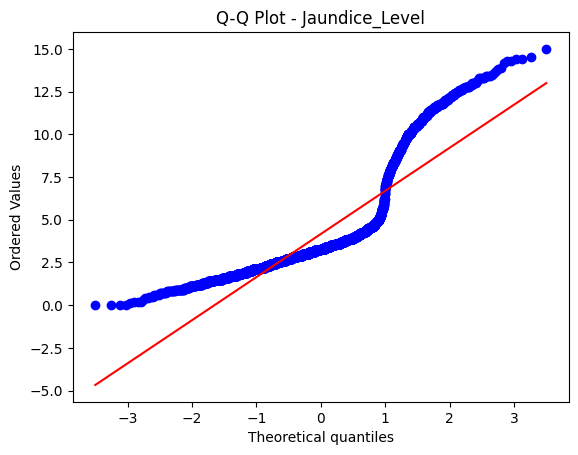

In [43]:
stats.probplot(full_df["jaundice_level_mg_dl"], dist="norm", plot=plt)
plt.title("Q-Q Plot - Jaundice_Level")
plt.show()

In [28]:
stat, p = shapiro(full_df["jaundice_level_mg_dl"])
print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Fail to reject H0: data looks normally distributed")
else:
    print("Reject H0: data is NOT normally distributed")

Shapiro-Wilk p-value: 1.4728029630813267e-53
Reject H0: data is NOT normally distributed


# Reflexes

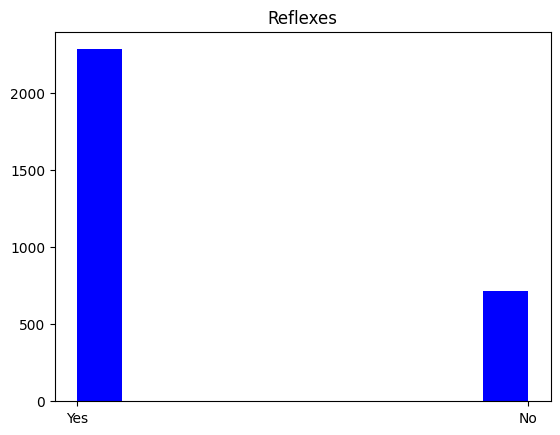

Yes: 2283
No: 717


In [29]:
#Plotting 
plt.title("Reflexes")
plt.hist(full_df["reflexes_normal"], color="blue")
plt.show()

yesReflex = (full_df["reflexes_normal"] == "Yes").sum()
noReflex = (full_df["reflexes_normal"] == "No").sum()
print(f"Yes: {yesReflex}")
print(f"No: {noReflex}")


## Chi Square test of independenc

### Gender


In [30]:
contingency_table = pd.crosstab(full_df['gender'], full_df['risk_level'])
print(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", dof)
print("P-value:", p_value)
print("Expected frequencies:\n", expected)

risk_level  At Risk  Healthy
gender                      
Female          174     1176
Male            224     1426
Chi-square statistic: 0.24766882885299535
Degrees of freedom: 1
P-value: 0.6187213309458668
Expected frequencies:
 [[ 179.1 1170.9]
 [ 218.9 1431.1]]


### Feeding

In [31]:
contingency_table = pd.crosstab(full_df['feeding_type'], full_df['risk_level'])
print(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", dof)
print("P-value:", p_value)
print("Expected frequencies:\n", expected)

risk_level     At Risk  Healthy
feeding_type                   
Breastfeeding      129      880
Formula            133      865
Mixed              136      857
Chi-square statistic: 0.36559082603491194
Degrees of freedom: 2
P-value: 0.832938546690523
Expected frequencies:
 [[133.86066667 875.13933333]
 [132.40133333 865.59866667]
 [131.738      861.262     ]]


### Immunization

In [32]:
contingency_table = pd.crosstab(full_df['immunizations_done'], full_df['risk_level'])
print(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", dof)
print("P-value:", p_value)
print("Expected frequencies:\n", expected)

risk_level          At Risk  Healthy
immunizations_done                  
No                      389     2411
Yes                       9      191
Chi-square statistic: 13.507801304755912
Degrees of freedom: 1
P-value: 0.00023757373198230646
Expected frequencies:
 [[ 371.46666667 2428.53333333]
 [  26.53333333  173.46666667]]


### Reflexes

In [33]:
contingency_table = pd.crosstab(full_df['reflexes_normal'], full_df['risk_level'])
print(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", dof)
print("P-value:", p_value)
print("Expected frequencies:\n", expected)

risk_level       At Risk  Healthy
reflexes_normal                  
No                    96      621
Yes                  302     1981
Chi-square statistic: 0.002275788677424081
Degrees of freedom: 1
P-value: 0.9619511683518632
Expected frequencies:
 [[  95.122  621.878]
 [ 302.878 1980.122]]


## Logistic Regression

In [34]:
#Making into binary
full_df["risk_level_binary"] = full_df["risk_level"].map({
    "Healthy": 0,
    "At Risk": 1
})

In [35]:
formula = """risk_level_binary ~ gestational_age_weeks + birth_weight_kg +
             birth_length_cm + birth_head_circumference_cm + weight_kg +
             length_cm + head_circumference_cm + temperature_c + heart_rate_bpm +
             respiratory_rate_bpm + oxygen_saturation + feeding_type +
             feeding_frequency_per_day + urine_output_count + stool_count +
             jaundice_level_mg_dl"""

In [49]:
model = smf.logit(formula=formula, data=full_df).fit()
modelsList.append(model)
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.189537
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      risk_level_binary   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2982
Method:                           MLE   Df Model:                           17
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.5158
Time:                        20:37:51   Log-Likelihood:                -568.61
converged:                       True   LL-Null:                       -1174.3
Covariance Type:            nonrobust   LLR p-value:                4.881e-247
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      39.1440     12.531      3.124      0.002   

In [48]:
# #Loop for equation 
# modelsList = []
# for i in range(1, 31):
#     print(f"Model Day {i}: ")
#     subset = full_df[full_df["age_days"] == i]
#     model = smf.logit(formula=formula, data=subset).fit()
#     modelsList.append(model)
#     print(model.summary())

Model Day 1: 
         Current function value: inf
         Iterations: 35


c:\Users\skyej\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\skyej\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


LinAlgError: Singular matrix

In [37]:
# #Getting significant factors each day
# index = 1
# for model in modelsList:
#     print(f"Day {index}:")
#     for var in model.params.index:
#         if model.pvalues[var] < 0.10:
#             print(f"{var}: {model.pvalues[var]}")
#     index += 1

Day 1:
Intercept: 0.0017851483338791533
temperature_c: 0.005955271961872006
heart_rate_bpm: 5.17883954295538e-28
oxygen_saturation: 2.876811279194904e-26
jaundice_level_mg_dl: 1.0371993982816852e-74
Day 2:
Intercept: 0.0017851483338791533
temperature_c: 0.005955271961872006
heart_rate_bpm: 5.17883954295538e-28
oxygen_saturation: 2.876811279194904e-26
jaundice_level_mg_dl: 1.0371993982816852e-74
Day 3:
Intercept: 0.0017851483338791533
temperature_c: 0.005955271961872006
heart_rate_bpm: 5.17883954295538e-28
oxygen_saturation: 2.876811279194904e-26
jaundice_level_mg_dl: 1.0371993982816852e-74
Day 4:
Intercept: 0.0017851483338791533
temperature_c: 0.005955271961872006
heart_rate_bpm: 5.17883954295538e-28
oxygen_saturation: 2.876811279194904e-26
jaundice_level_mg_dl: 1.0371993982816852e-74
Day 5:
Intercept: 0.0017851483338791533
temperature_c: 0.005955271961872006
heart_rate_bpm: 5.17883954295538e-28
oxygen_saturation: 2.876811279194904e-26
jaundice_level_mg_dl: 1.0371993982816852e-74
Day 6

In [50]:
formula2 = """risk_level_binary ~ temperature_c + heart_rate_bpm +
             oxygen_saturation +
             jaundice_level_mg_dl"""

In [52]:
#Loop for equation 
modelsList = []
for i in range(1, 31):
    print(f"Model Day {i}: ")
    subset = full_df[full_df["age_days"] == i]
    model = smf.logit(formula=formula2, data=subset).fit()
    modelsList.append(model)
    print(model.summary())

Model Day 1: 
Optimization terminated successfully.
         Current function value: 0.083560
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:      risk_level_binary   No. Observations:                  100
Model:                          Logit   Df Residuals:                       95
Method:                           MLE   Df Model:                            4
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.6318
Time:                        20:53:20   Log-Likelihood:                -8.3560
converged:                       True   LL-Null:                       -22.697
Covariance Type:            nonrobust   LLR p-value:                 9.073e-06
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               56.9041    135.211      0.421      0.674    -208.

c:\Users\skyej\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\skyej\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\skyej\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\skyej\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\skyej\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\discrete\discrete_model.py:23

LinAlgError: Singular matrix

In [40]:
#Getting significant factors each day
index = 1
for model in modelsList:
    print(f"Day {index}:")
    for var in model.params.index:
        if model.pvalues[var] < 0.10:
            print(f"{var}: {model.pvalues[var]}")
    index += 1

Day 1:
Intercept: 0.0006823280499784357
temperature_c: 0.007399045070663387
heart_rate_bpm: 4.646581321767987e-28
oxygen_saturation: 2.9180105128767923e-26
jaundice_level_mg_dl: 1.1435995177010547e-118
Day 2:
Intercept: 0.0006823280499784357
temperature_c: 0.007399045070663387
heart_rate_bpm: 4.646581321767987e-28
oxygen_saturation: 2.9180105128767923e-26
jaundice_level_mg_dl: 1.1435995177010547e-118
Day 3:
Intercept: 0.0006823280499784357
temperature_c: 0.007399045070663387
heart_rate_bpm: 4.646581321767987e-28
oxygen_saturation: 2.9180105128767923e-26
jaundice_level_mg_dl: 1.1435995177010547e-118
Day 4:
Intercept: 0.0006823280499784357
temperature_c: 0.007399045070663387
heart_rate_bpm: 4.646581321767987e-28
oxygen_saturation: 2.9180105128767923e-26
jaundice_level_mg_dl: 1.1435995177010547e-118
Day 5:
Intercept: 0.0006823280499784357
temperature_c: 0.007399045070663387
heart_rate_bpm: 4.646581321767987e-28
oxygen_saturation: 2.9180105128767923e-26
jaundice_level_mg_dl: 1.143599517701